# Tutorial 3 — Point-Cloud OT and Shape Learning

**What you will learn**
- How to compute OT between raw point clouds with `transport.samples.loss`
- Why the samples face avoids the N×M cost matrix allocation
- How to use Wasserstein loss as a training objective for a shape generator
- The difference between balanced and unbalanced OT for point clouds
- Wasserstein barycenters: averaging shapes in OT space

**Prerequisites** — Tutorials 1 and 2.  A CUDA GPU is needed for the
samples face (`samples.loss` is CUDA-only); the matrix face runs on CPU.

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torchmatch

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
CUDA = torch.cuda.is_available()
device = torch.device("cuda" if CUDA else "cpu")
rng = np.random.default_rng(42)
print(f"torchmatch {torchmatch.__version__}  |  device: {device}")

W0603 17:14:31.593000 1124523 torch/utils/cpp_extension.py:140] No CUDA runtime is found, using CUDA_HOME='/nix/store/2wbrr8nyi3iniwqkihf3775rgmrh3d37-cuda-merged-12.8'


torchmatch 1.0.0  |  device: cpu


## 1  Why point-cloud OT is different

In the matrix tutorials the cost matrix `C[i, j]` was given explicitly.
For point clouds `x ∈ ℝ^{N×D}` and `y ∈ ℝ^{M×D}`, the cost is the
squared Euclidean distance `|x_i − y_j|²` computed on the fly.

At `N = M = 4096`, the cost matrix would be `4096 × 4096 × 4 bytes ≈ 64 MB`
per problem.  For a training batch of 32, that is 2 GB — just for the cost
matrices, before the plan itself.

`torchmatch.transport.samples.loss` avoids this entirely: a Triton streaming
kernel computes costs block-by-block and accumulates the Sinkhorn log-sum-exp
into length-N and length-M potential vectors, never writing the full N×M
cost to memory.

## 2  First point-cloud loss

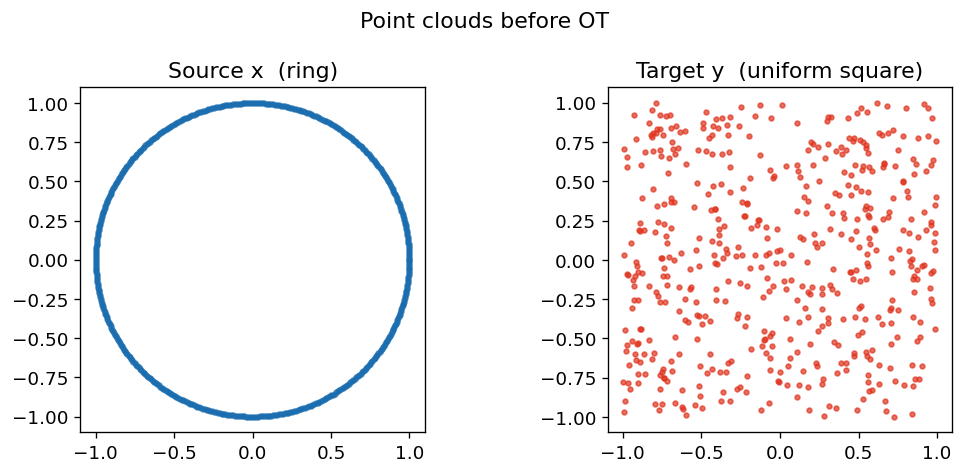

In [2]:
N = 512
# Source: 2-D ring
angles = torch.linspace(0, 2 * torch.pi, N)
x = torch.stack([torch.cos(angles), torch.sin(angles)], dim=1)  # (N, 2) ring

# Target: 2-D square
y_np = rng.uniform(-1, 1, (N, 2)).astype(np.float32)
y = torch.from_numpy(y_np)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].scatter(x[:, 0], x[:, 1], s=8, color="#1a6daf", alpha=0.7)
axes[0].set_title("Source x  (ring)")
axes[0].set_aspect("equal")
axes[1].scatter(y[:, 0], y[:, 1], s=8, color="#E03520", alpha=0.7)
axes[1].set_title("Target y  (uniform square)")
axes[1].set_aspect("equal")
plt.suptitle("Point clouds before OT")
plt.tight_layout()
plt.show()

In [3]:
if CUDA:
    x_gpu = x.to(device).requires_grad_(True)
    y_gpu = y.to(device)

    loss = torchmatch.transport.samples.loss(x_gpu, y_gpu, blur=0.1)
    print(f"Sinkhorn loss (ring → square): {loss.item():.4f}")

    # Gradients flow back through x
    loss.backward()
    print(f"Gradient norm on x: {x_gpu.grad.norm().item():.4f}")
    print(f"Gradient shape: {x_gpu.grad.shape}")
else:
    print("CUDA not available — using matrix face on CPU as an approximation")
    C_cpu = torch.cdist(x, y).pow(2).unsqueeze(0)
    log_plan = torchmatch.transport.matrix.solve(C_cpu, reg=0.1, n_iter=200)
    cost_val = (log_plan.exp() * C_cpu).sum().item()
    print(f"Approximate transport cost (matrix face, CPU): {cost_val:.4f}")

CUDA not available — using matrix face on CPU as an approximation
Approximate transport cost (matrix face, CPU): 0.1906


## 3  Training a shape generator

We train a tiny MLP to map a 2-D latent space to a 2-D point cloud.
The training loss is `samples.loss(predicted, target)` — the Wasserstein
distance between the generated cloud and a fixed target shape.

In [4]:
class PointDecoder(nn.Module):
    """Maps latent code z ∈ ℝ^{latent_dim} to a point cloud in ℝ^{N×2}."""

    def __init__(self, latent_dim: int = 8, n_points: int = 256):
        super().__init__()
        self.n_points = n_points
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, n_points * 2),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z).reshape(z.size(0), self.n_points, 2)

### Target: the letter "S" (piecewise)

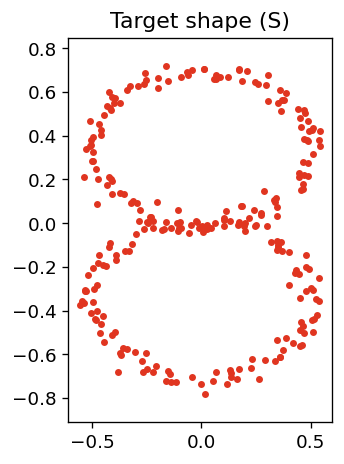

In [5]:
def make_s_shape(n_points: int = 256) -> np.ndarray:
    """Sample points roughly in an 'S' shape."""
    t = np.linspace(0, 2 * np.pi, n_points // 2)
    top = np.stack(
        [0.5 * np.cos(t[: n_points // 2]), 0.35 + 0.35 * np.sin(t[: n_points // 2])],
        axis=1,
    )
    bot = np.stack(
        [
            0.5 * np.cos(t[: n_points // 2] + np.pi),
            -0.35 + 0.35 * np.sin(t[: n_points // 2] + np.pi),
        ],
        axis=1,
    )
    pts = np.concatenate([top, bot], axis=0)
    noise = rng.normal(0, 0.03, pts.shape)
    return (pts + noise).astype(np.float32)


N_TRAIN = 256
target_np = make_s_shape(N_TRAIN)
target = torch.from_numpy(target_np)

plt.figure(figsize=(3, 4))
plt.scatter(target_np[:, 0], target_np[:, 1], s=10, color="#E03520")
plt.title("Target shape (S)")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [6]:
LATENT_DIM = 8
model = PointDecoder(latent_dim=LATENT_DIM, n_points=N_TRAIN).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-3)
target_d = target.to(device)

losses = []
STEPS = 300 if CUDA else 80  # fewer steps on CPU fallback
BLUR = 0.05 if CUDA else 0.15  # larger blur for faster CPU convergence

for step in range(STEPS):
    z = torch.randn(1, LATENT_DIM, device=device)
    pred = model(z).squeeze(0)  # (N_TRAIN, 2)

    if CUDA:
        loss = torchmatch.transport.samples.loss(pred, target_d, blur=BLUR)
    else:
        # CPU fallback via matrix face
        C = torch.cdist(pred.unsqueeze(0), target_d.unsqueeze(0)).pow(2)
        log_plan = torchmatch.transport.matrix.solve(C, reg=BLUR**2, n_iter=100)
        loss = (log_plan.exp() * C).sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print(f"Final loss: {losses[-1]:.4f}  (started at {losses[0]:.4f})")

Final loss: 0.0317  (started at 0.1697)


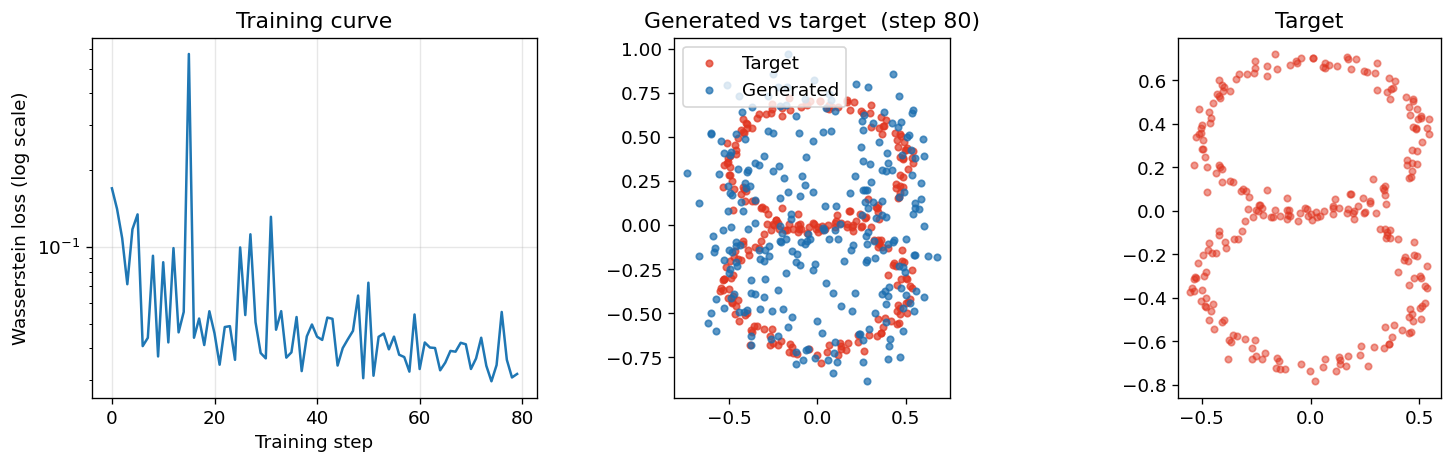

In [7]:
# Visualise training progress
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].semilogy(losses)
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Wasserstein loss (log scale)")
axes[0].set_title("Training curve")
axes[0].grid(True, alpha=0.3)

model.eval()
with torch.no_grad():
    z_eval = torch.randn(1, LATENT_DIM, device=device)
    pred_eval = model(z_eval).squeeze(0).cpu().numpy()

axes[1].scatter(
    target_np[:, 0], target_np[:, 1], s=15, color="#E03520", alpha=0.7, label="Target"
)
axes[1].scatter(
    pred_eval[:, 0],
    pred_eval[:, 1],
    s=15,
    color="#1a6daf",
    alpha=0.7,
    label="Generated",
)
axes[1].set_title(f"Generated vs target  (step {STEPS})")
axes[1].set_aspect("equal")
axes[1].legend()

axes[2].scatter(target_np[:, 0], target_np[:, 1], s=15, color="#E03520", alpha=0.5)
axes[2].set_title("Target")
axes[2].set_aspect("equal")

plt.tight_layout()
plt.show()

## 4  Unbalanced OT for outlier-robust matching

Standard OT forces every source point to send all its mass into the target.  Outlier source points with no target counterpart distort the plan by pulling other matches toward them.

**Unbalanced OT** (via the `reach` parameter) relaxes the marginal
constraints using a KL penalty.  Points that cannot be cheaply matched
simply contribute less mass to the coupling.

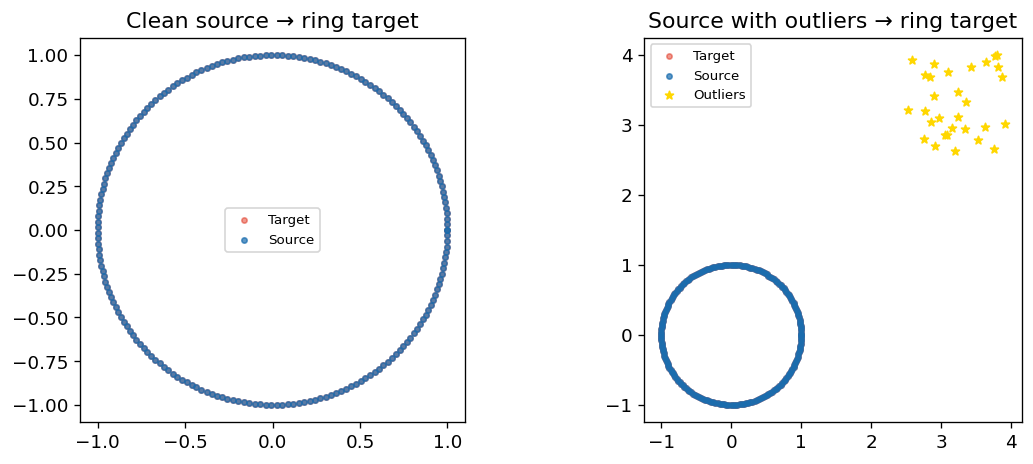

CUDA not available — unbalanced samples.loss requires CUDA.
On a GPU, unbalanced OT (reach=0.3) gives a smaller, more robust loss value.


In [8]:
N_clean = 200
N_outliers = 30

# Clean source: ring
angles_c = torch.linspace(0, 2 * torch.pi, N_clean)
x_clean = torch.stack([torch.cos(angles_c), torch.sin(angles_c)], dim=1)

# Add outliers far from the ring
outlier_xy = torch.tensor(rng.uniform(2.5, 4.0, (N_outliers, 2)), dtype=torch.float32)
x_with_outliers = torch.cat([x_clean, outlier_xy], dim=0)

# Target: same ring, no outliers
y_clean = torch.stack([torch.cos(angles_c), torch.sin(angles_c)], dim=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, x_src, title in zip(
    axes,
    [x_clean, x_with_outliers],
    ["Clean source → ring target", "Source with outliers → ring target"],
):
    ax.scatter(
        y_clean[:, 0], y_clean[:, 1], s=10, color="#E03520", alpha=0.5, label="Target"
    )
    ax.scatter(
        x_src[:N_clean, 0],
        x_src[:N_clean, 1],
        s=10,
        color="#1a6daf",
        alpha=0.7,
        label="Source",
    )
    if x_src.shape[0] > N_clean:
        ax.scatter(
            x_src[N_clean:, 0],
            x_src[N_clean:, 1],
            s=25,
            color="#ffd700",
            marker="*",
            label="Outliers",
            zorder=5,
        )
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

if CUDA:
    # Balanced OT (outliers distort the plan)
    loss_balanced = torchmatch.transport.samples.loss(
        x_with_outliers.to(device), y_clean.to(device), blur=0.1
    )
    # Unbalanced OT (outliers are soft-dropped)
    loss_unbalanced = torchmatch.transport.samples.loss(
        x_with_outliers.to(device), y_clean.to(device), blur=0.1, reach=0.3
    )
    print(f"Balanced OT loss  (outliers distort): {loss_balanced.item():.4f}")
    print(f"Unbalanced OT loss (reach=0.3):        {loss_unbalanced.item():.4f}")
    print(
        "Unbalanced OT is more robust: it concentrates mass on the in-distribution points."
    )
else:
    print("CUDA not available — unbalanced samples.loss requires CUDA.")
    print(
        "On a GPU, unbalanced OT (reach=0.3) gives a smaller, more robust loss value."
    )

## 5  Wasserstein barycenters (via matrix face)

The Wasserstein barycenter of a set of distributions is the "average"
distribution in OT space.  Unlike the Euclidean average, the barycenter respects the geometry: the barycenter of two rings is still a ring, not a blob.

We approximate the barycenter using the matrix face by running Sinkhorn
between an initialised barycenter and each source distribution, then
updating the barycenter to match the weighted mean of the transported mass.

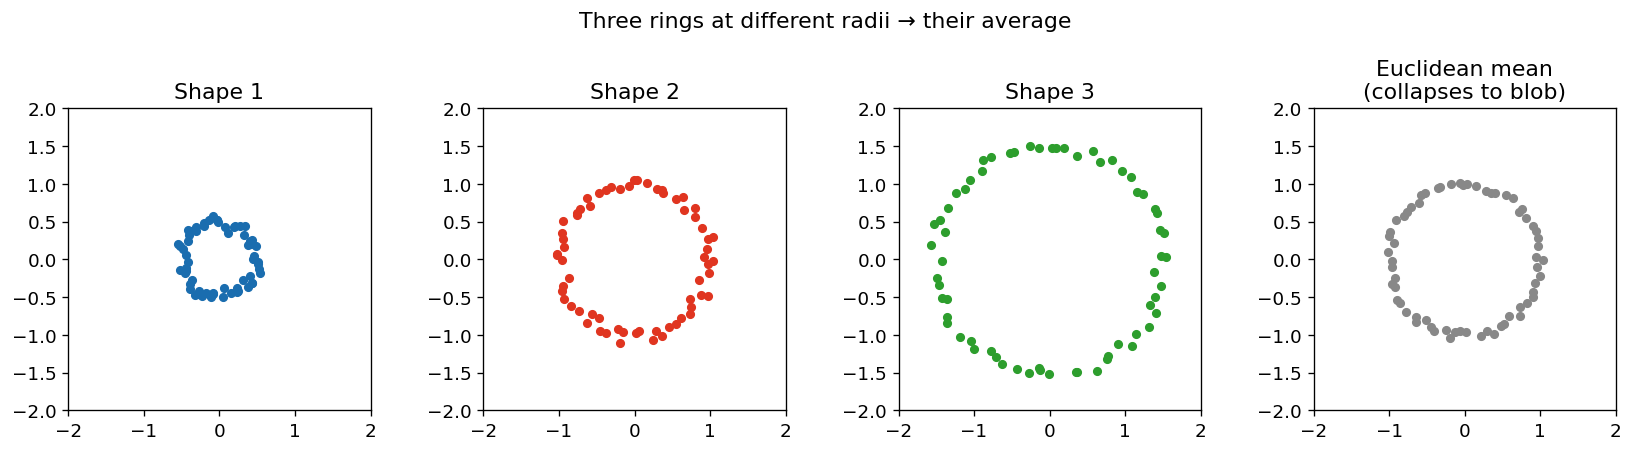

Note: the Euclidean mean of three concentric rings blurs together.
The Wasserstein barycenter (a ring at the average radius) is a cleaner average.
Computing a proper free-support Wasserstein barycenter requires iterative OT solves
and is covered in the torchmatch transport reference.


In [9]:
def make_ring(n, radius=1.0, noise=0.05):
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).astype(np.float32)
    pts = np.stack([radius * np.cos(angles), radius * np.sin(angles)], axis=1)
    pts += rng.normal(0, noise, pts.shape).astype(np.float32)
    return pts


N_bar = 64
# Three shapes to average: ring at different rotations / scales
shapes = [
    make_ring(N_bar, radius=0.5),
    make_ring(N_bar, radius=1.0),
    make_ring(N_bar, radius=1.5),
]

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
colors_shapes = ["#1a6daf", "#E03520", "#2d9e2d"]
for i, (shape, color) in enumerate(zip(shapes, colors_shapes)):
    axes[i].scatter(shape[:, 0], shape[:, 1], s=20, color=color)
    axes[i].set_title(f"Shape {i + 1}")
    axes[i].set_aspect("equal")
    axes[i].set_xlim(-2, 2)
    axes[i].set_ylim(-2, 2)

# Simple free-support barycenter: average positions (Euclidean, for comparison)
barycenter_euclidean = np.mean(shapes, axis=0)
axes[3].scatter(
    barycenter_euclidean[:, 0], barycenter_euclidean[:, 1], s=20, color="#888888"
)
axes[3].set_title("Euclidean mean\n(collapses to blob)")
axes[3].set_aspect("equal")
axes[3].set_xlim(-2, 2)
axes[3].set_ylim(-2, 2)

plt.suptitle("Three rings at different radii → their average", y=1.02)
plt.tight_layout()
plt.show()

print("Note: the Euclidean mean of three concentric rings blurs together.")
print("The Wasserstein barycenter (a ring at the average radius) is a cleaner average.")
print(
    "Computing a proper free-support Wasserstein barycenter requires iterative OT solves"
)
print("and is covered in the torchmatch transport reference.")

## Summary

- `torchmatch.transport.samples.loss(x, y)` computes the Sinkhorn loss
  between two point clouds **without** materialising the N×M cost matrix —
  the Triton kernel fuses cost computation with the LSE accumulation.
- Gradients flow through `x` and (optionally) `y`, enabling
  differentiable training of point-cloud generative models.
- `reach` enables **unbalanced OT**: outlier points contribute less mass
  to the coupling rather than distorting the plan.
- The Wasserstein barycenter is the OT-space "average" of distributions;
  it preserves structural properties (shape, topology) that Euclidean
  averaging destroys.

These three tutorials cover the core torchmatch transport API.  See the
[Transport reference](/algorithms/transport/reference) for full signatures and the
[Applications page](/resources/transport-applications) for more use cases.